# Bac à sable pour outils

## importations de base

In [1]:
# Résoud le problème des modules introuvables si pas dans le même dossier que le notebook
import sys
sys.path.append("..")
# Autoreload pour ne pas avoir à redémarrer le kernel à chaque changement d'un module
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from typing import List, Union


from scipy.optimize import curve_fit


# Baseline

## Valeurs pour tests (points expérimentaux et modélisation selon ComBase)

In [21]:
#Poutlry Salmonella Baranyi_complet ComBaseID SOscar36_5

dummy_params_baranyi = {'Initial Value': 4.309, 'Lag': 1.0775, 'Maximum Rate': 0.685, 'Final Value': 9.835}

dummy_val_baranyi = {
    'time': [0, 0.32799999999999996, 0.6559999999999999, 0.9839999999999999, 1.3119999999999998, 1.6399999999999997, 1.9679999999999997, 2.296, 2.6239999999999997,
                        2.9519999999999995, 3.2799999999999994, 3.6079999999999997, 3.9359999999999995, 4.263999999999999, 4.592, 4.919999999999999, 5.247999999999999, 5.576,
                        5.903999999999999, 6.231999999999999, 6.559999999999999, 6.887999999999999, 7.215999999999999, 7.543999999999999, 7.871999999999999, 8.2, 8.527999999999999,
                        8.855999999999998, 9.184, 9.511999999999999, 9.839999999999998, 10.168, 10.495999999999999, 10.823999999999998, 11.152, 11.479999999999999, 11.807999999999998,
                        12.136, 12.463999999999999, 12.791999999999998, 13.119999999999997, 13.447999999999999, 13.775999999999998, 14.103999999999997, 14.431999999999999,
                        14.759999999999998, 15.087999999999997, 15.415999999999999, 15.743999999999998, 16.4],
    'logC': [4.308712286482676, 4.384066439911397, 4.478959357392312, 4.59453269179504, 4.730569480263076, 4.885548688727838, 5.057007945895253, 5.242045810498657,
                        5.43777495995431, 5.641619555634065, 5.8514469865044605, 6.065578747650244, 6.282734717730072, 6.501951599444913, 6.722498600081494, 6.9437998267655185,
                        7.165364563413286, 7.386722174017358, 7.607356223188182, 7.826631540338278, 8.043708264469785, 8.257439323833239, 8.46625457112362, 8.6680493872788,
                        8.860120835408484, 9.039226375548807, 9.201856628172537, 9.344769968753495, 9.465698657067566, 9.563959529905274, 9.640655668092602, 9.698352275279305,
                        9.740410865221353, 9.770305415365101, 9.791148740957704, 9.805477581991411, 9.815229480694583, 9.821820046831068, 9.82625270430541, 9.829224251232908,
                        9.831211900611839, 9.832539450073028, 9.833425235512934, 9.834015867167928, 9.834409518272565, 9.834671805522992, 9.834846531244626, 9.834962911460941,
                        9.835040422448362, 9.835126419571193]
    }

dummy_param_linear = {'Initial Value': 4.816, 'Maximum Rate': 0.392}

dummy_val_linear = {
    'time': [ 0, 0.32799999999999996, 0.6559999999999999, 0.9839999999999999, 1.3119999999999998, 1.6399999999999997, 1.9679999999999997, 2.296, 2.6239999999999997, 2.9519999999999995,
             3.2799999999999994, 3.6079999999999997, 3.9359999999999995, 4.263999999999999, 4.592, 4.919999999999999, 5.247999999999999, 5.576, 5.903999999999999, 6.231999999999999,
             6.559999999999999, 6.887999999999999, 7.215999999999999, 7.543999999999999, 7.871999999999999, 8.2, 8.527999999999999, 8.855999999999998, 9.184, 9.511999999999999,
             9.839999999999998, 10.168, 10.495999999999999, 10.823999999999998, 11.152, 11.479999999999999, 11.807999999999998, 12.136, 12.463999999999999, 12.791999999999998,
             13.119999999999997, 13.447999999999999, 13.775999999999998, 14.103999999999997, 14.431999999999999, 14.759999999999998, 15.087999999999997, 15.415999999999999,
             15.743999999999998, 16.4],
    'logC': [4.8158857650406945, 4.944543433574419, 5.073201102108144, 5.201858770641869, 5.330516439175594, 5.459174107709319, 5.587831776243044, 5.716489444776768, 5.845147113310492,
             5.973804781844217, 6.102462450377942, 6.231120118911667, 6.359777787445392, 6.488435455979117, 6.6170931245128415, 6.745750793046566, 6.874408461580291, 7.003066130114016,
             7.131723798647741, 7.260381467181466, 7.3890391357151906, 7.517696804248915, 7.64635447278264, 7.775012141316364, 7.90366980985009, 8.032327478383815, 8.16098514691754,
             8.289642815451263, 8.41830048398499, 8.546958152518712, 8.675615821052437, 8.804273489586162, 8.932931158119889, 9.061588826653612, 9.190246495187338, 9.318904163721061,
             9.447561832254786, 9.576219500788511, 9.704877169322236, 9.83353483785596, 9.962192506389686, 10.09085017492341, 10.219507843457135, 10.34816551199086, 10.476823180524585,
             10.60548084905831, 10.734138517592033, 10.86279618612576, 10.991453854659484, 11.248769191726934]
    }

dummy_train = {
    'time': [1.2,2.1,2.9,3.5,4.1,4.9,5.9,7,8.6,11.1,16.4],
    'logC': [4.76,5.08,5.46,6.06,6.28,7.11,7.59,8.47,9.11,9.41,10.2]
    }

## Classe ClassicalModel : modèles de croissance micro classiques "maison" (pas prévu pour intégration dans pipeline)

In [4]:
#dans ml_logic.baseline
from ml_logic.baseline import ClassicalModel

## Affichage des modèles "maison"

In [5]:
def plot_models(our_model, combase_model, datapoints):

    # Trace les valeurs de notre modèle, du modèle Combase, et les points expérimentaux
    # Les données sont sous la forme de dict {'time': [temps], 'logC';[logCs]}

    fig, ax = plt.subplots(figsize=(6, 4))

    # Courbe modèle (rouge)
    sns.lineplot(
        x=our_model['time'],
        y=our_model['logC'],
        ax=ax,
        color="red",
        label="Our model"
    )

    # Courbe dummy (bleue)
    sns.lineplot(
        x=combase_model['time'],
        y=combase_model['logC'],
        ax=ax,
        color="blue",
        label="ComBase model"
    )

    # Points d'entraînement (ronds noirs)
    sns.scatterplot(
        x=datapoints['time'],
        y=datapoints['logC'],
        ax=ax,
        color="black",
        marker="o",
        s=50,
        label="Train data"
    )

    ax.set_xlabel("Time")
    ax.set_ylabel("logC")
    ax.legend()

    plt.tight_layout()
    plt.show()

    return fig, ax


## Test des modèles "maison" : ✔


model.params={'logC0': 4.815885765040695, 'mu': 0.3922489894320881}


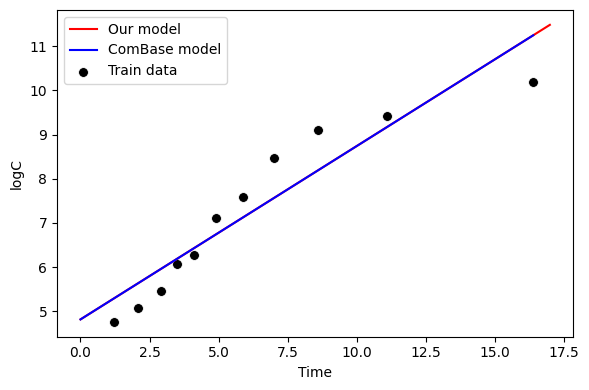

Text(0.5, 1.0, 'Linear model')

In [6]:
#Test modèle linéaire
model = ClassicalModel()
model.fit(dummy_train['time'], dummy_train['logC'], model='linear')
print(f'{model.params=}')
t_model = np.linspace(0, 17, 20)
logC_model = model.predict(t_model)
fig, ax = plot_models({'time':t_model, 'logC':logC_model},
            dummy_val_linear,
            dummy_train)
ax.set_title('Linear model')

model2.params={'Initial Value': 4.499529078333809, 'Lag': 1.331097371518046, 'Maximum Rate': 1.5632372389335185, 'Final Value': 9.800124912213905}


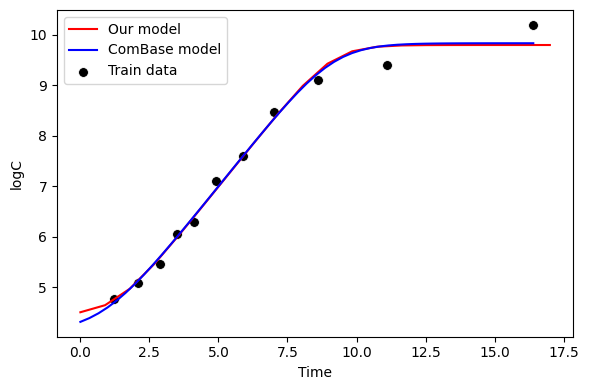

Text(0.5, 1.0, 'Baranyi and Roberts (1994) model')

In [7]:
#Test modèle Baranyi
model2 = ClassicalModel()
model2.fit(dummy_train['time'], dummy_train['logC'], model='baranyi')
print(f'{model2.params=}')
t_model = np.linspace(0, 17, 20)
logC_model = model2.predict(t_model)
fig, ax = plot_models({'time':t_model, 'logC':logC_model},
            dummy_val_baranyi,
            dummy_train)
ax.set_title('Baranyi and Roberts (1994) model')

Paramètres estimés :
{'A': 25517279328.91278, 'Ea': 74988.50500297689, 'R': 8.314462618, 'x_in_celsius': True}


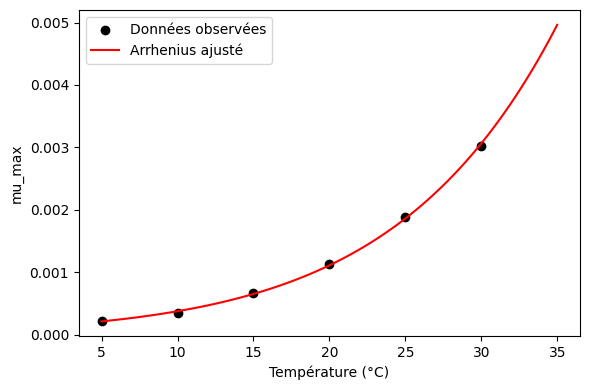


Comparaison :
A vrai      : 2.50e+10
A estimé    : 2.55e+10
Ea vrai (J/mol)   : 75000
Ea estimé (J/mol) : 74989


In [8]:
#Test modèle Arrhénius
# -----------------------------
# 1️⃣ Données "vraies"
# -----------------------------

# Constantes physiques
R = 8.314462618  # J/mol/K

# Paramètres vrais (inconnus du modèle)
A_true = 2.5e10        # facteur pré-exponentiel
Ea_true = 75000        # J/mol (75 kJ/mol)

# Températures expérimentales (°C)
T_celsius = np.array([5, 10, 15, 20, 25, 30])

# Conversion en Kelvin
T_kelvin = T_celsius + 273.15

# Génération du paramètre primaire (ex: mu_max)
mu_true = A_true * np.exp(-Ea_true / (R * T_kelvin))

# Ajout bruit expérimental (5%)
noise = np.random.normal(0, 0.05 * mu_true)
mu_observed = mu_true + noise

# -----------------------------
# 2️⃣ Fit du modèle Arrhenius
# -----------------------------

model = ClassicalModel()
model.fit(T_celsius.tolist(), mu_observed.tolist(), model="arrhenius")

print("Paramètres estimés :")
print(model.params)

# -----------------------------
# 3️⃣ Prédiction
# -----------------------------

T_test = np.linspace(5, 35, 100)
mu_pred = model.predict(T_test.tolist())

# -----------------------------
# 4️⃣ Visualisation
# -----------------------------

plt.figure(figsize=(6, 4))

plt.scatter(T_celsius, mu_observed, color="black", label="Données observées")
plt.plot(T_test, mu_pred, color="red", label="Arrhenius ajusté")

plt.xlabel("Température (°C)")
plt.ylabel("mu_max")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 5️⃣ Comparaison paramètres
# -----------------------------

print("\nComparaison :")
print(f"A vrai      : {A_true:.2e}")
print(f"A estimé    : {model.params['A']:.2e}")
print(f"Ea vrai (J/mol)   : {Ea_true:.0f}")
print(f"Ea estimé (J/mol) : {model.params['Ea']:.0f}")


## Test des modèles compatibles sklearn ✔

In [12]:
from ml_logic.sk_baseline import ClassicalModelRegressor

model2_not_sklearn.params={'Initial Value': 4.499529078333809, 'Lag': 1.331097371518046, 'Maximum Rate': 1.5632372389335185, 'Final Value': 9.800124912213905}


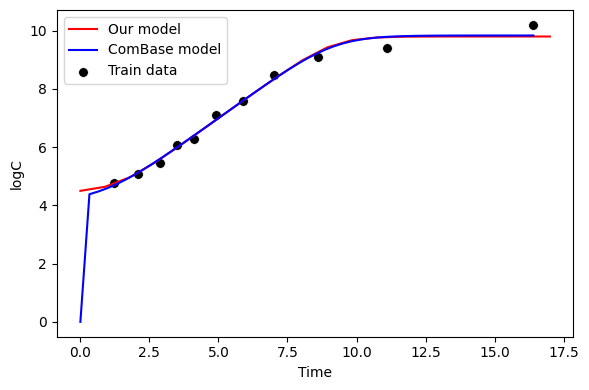

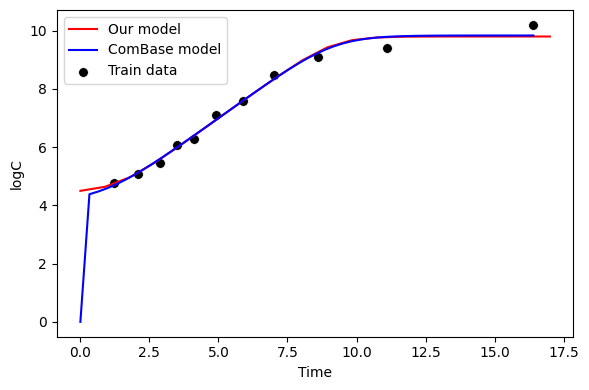

In [20]:
#Test modèle Baranyi - non sklearn
model2_not_sklearn = ClassicalModel()
model2_not_sklearn.fit(dummy_train['time'], dummy_train['logC'], model='baranyi')
print(f'{model2_not_sklearn.params=}')
t_model = np.linspace(0, 17, 20)
logC_model2_not_sklearn = model2_not_sklearn.predict(t_model)

fig1, ax1 = plot_models({'time':t_model, 'logC':logC_model2_not_sklearn},
            dummy_val_baranyi,
            dummy_train)
ax1.set_title('Baranyi and Roberts (1994) model - not sklearn compatible')
plt.show()

#Test modèle Baranyi - sklearn

model2_sklearn = ClassicalModelRegressor(model='baranyi')
model2_sklearn.fit(dummy_train['time'], dummy_train['logC'])
logC_model2_sklearn = model2_sklearn.predict(t_model)
fig2, ax2 = plot_models({'time':t_model, 'logC':logC_model2_sklearn},
            dummy_val_baranyi,
            dummy_train)
ax2.set_title('Baranyi and Roberts (1994) model - sklearn compatible')
plt.show()

In [15]:
model2_sklearn.params_.keys()

dict_keys(['Initial Value', 'Lag', 'Maximum Rate', 'Final Value'])

# Test des modules explications et recettes

In [ ]:
from interface import explanations
exp = explanations.risk_explanation(['Salmonella', 'Listeria'], max_output_tokens=2000)
display(Markdown(exp))

In [ ]:
from interface import recipes
raw_beef = recipes.recipe_suggestion(ingredient='beef', cooking='raw', provider='auto', max_output_tokens=5000)
display(Markdown(raw_beef))